# Preprocessing Concatenated ECG Data

Các bước tiền xử lý dữ liệu ECG đã được nối (concatenated) theo specifications trong `preprocess.md`:
1. Load & kiểm tra dữ liệu
2. Xác định sampling rate
3. Normalize Voltage
4. Xử lý outliers (IQR method)
5. Tạo sliding windows
6. Kiểm tra class balance
7. Xử lý mất cân bằng (nếu cần)
8. Split train/val/test (stratified)
9. Lưu dữ liệu

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

## Bước 1: Load và Kiểm Tra Dữ Liệu

Quét thư mục `data/concatenated/` để tìm tất cả file CSV và kiểm tra tính toàn vẹn dữ liệu.

In [7]:
# ==============================
# 1. Load all files from concatenated directory
# ==============================

concate_dir = "data/concatenated"
csv_files = glob.glob(f"{concate_dir}/**/*.csv", recursive=True)
csv_files = sorted(csv_files)

print(f"Found {len(csv_files)} CSV files")
print(f"Sample files: {csv_files[:5]}")
print()

# Load all data with file tracking
all_data = []
file_info = []  # Track (file_path, label_from_folder)

for i, file_path in enumerate(csv_files):
    try:
        df = pd.read_csv(file_path)
        
        # Extract label from directory (pure_0, pure_1, mixed_0, etc.)
        folder = os.path.basename(os.path.dirname(file_path))
        label_from_folder = int(folder.split('_')[1])
        
        # Add file tracking columns
        df['_file_path'] = file_path
        df['Label_from_folder'] = label_from_folder
        
        all_data.append(df)
        file_info.append({
            'file_path': file_path,
            'folder': folder,
            'label_from_folder': label_from_folder,
            'rows': len(df)
        })
        
        if (i + 1) % 20 == 0:
            print(f"Loaded {i + 1}/{len(csv_files)} files...")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

print(f"\n✓ Successfully loaded {len(all_data)} files")

# Combine all data
df_combined = pd.concat(all_data, ignore_index=True)
print(f"\nTotal rows: {len(df_combined):,}")
print(f"Columns: {list(df_combined.columns)}")
print(f"Data types:\n{df_combined.dtypes}")
print(f"\nFirst few rows:")
print(df_combined.head())

Found 81 CSV files
Sample files: ['data/concatenated\\mixed_0\\mixed_0_001.csv', 'data/concatenated\\mixed_0\\mixed_0_002.csv', 'data/concatenated\\mixed_0\\mixed_0_003.csv', 'data/concatenated\\mixed_0\\mixed_0_004.csv', 'data/concatenated\\mixed_0\\mixed_0_005.csv']

Loaded 20/81 files...
Loaded 40/81 files...
Loaded 60/81 files...
Loaded 80/81 files...

✓ Successfully loaded 81 files

Total rows: 12,503,174
Columns: ['Time', 'Voltage', 'Peak', '_file_path', 'Label_from_folder']
Data types:
Time                 float64
Voltage              float64
Peak                   int64
_file_path            object
Label_from_folder      int64
dtype: object

First few rows:
       Time   Voltage  Peak                                 _file_path  \
0  0.000000  0.942693     3  data/concatenated\mixed_0\mixed_0_001.csv   
1  0.003906  0.970711     0  data/concatenated\mixed_0\mixed_0_001.csv   
2  0.007812  0.926919     0  data/concatenated\mixed_0\mixed_0_001.csv   
3  0.011719  0.628375     0  d

In [10]:
# ==============================
# 1b. Data quality checks
# ==============================

print("=" * 70)
print("DATA QUALITY CHECKS")
print("=" * 70)

# Check for missing values
missing_values = df_combined.isnull().sum()
print(f"\nMissing values per column:")
print(missing_values)
print(f"Total missing: {missing_values.sum()}")

# Check for duplicates
duplicates = df_combined.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Check data ranges
print(f"\nData ranges:")
print(df_combined[['Time', 'Voltage', 'Peak', 'Label_from_folder']].describe())

# ============================================================
# Compare Label (from CSV) vs Label_from_folder (from folder)
# ============================================================
print(f"\n{'='*70}")
print("LABEL CONSISTENCY CHECK")
print(f"{'='*70}")


print(f"\nLabel_from_folder distribution (FROM FOLDER NAME):")
print(df_combined['Label_from_folder'].value_counts().sort_index())


# Check for invalid values in Label_from_folder
invalid_labels = (df_combined['Label_from_folder'] < 0) | (df_combined['Label_from_folder'] > 3)
print(f"\nInvalid labels (not in [0,1,2,3]): {invalid_labels.sum()}")

DATA QUALITY CHECKS

Missing values per column:
Time                 0
Voltage              0
Peak                 0
_file_path           0
Label_from_folder    0
dtype: int64
Total missing: 0

Duplicate rows: 0

Data ranges:
               Time       Voltage          Peak  Label_from_folder
count  1.250317e+07  1.250317e+07  1.250317e+07       1.250317e+07
mean   4.719671e+02  2.040028e-01  8.831294e-02       1.394710e+00
std    3.830478e+02  2.171900e-01  5.621636e-01       1.061438e+00
min    0.000000e+00 -4.969831e-01  0.000000e+00       0.000000e+00
25%    1.507422e+02  6.040577e-02  0.000000e+00       1.000000e+00
50%    3.047871e+02  1.729295e-01  0.000000e+00       1.000000e+00
75%    7.931836e+02  3.129935e-01  0.000000e+00       2.000000e+00
max    1.282293e+03  1.299449e+00  5.000000e+00       3.000000e+00

LABEL CONSISTENCY CHECK

Label_from_folder distribution (FROM FOLDER NAME):
Label_from_folder
0    3120589
1    3756040
2    3197375
3    2429170
Name: count, dtype: int6

In [16]:
# ==============================
# FIX: Unwrap Time column (xử lý time reset)
# ==============================

# Phát hiện nơi Time bị reset (time difference < 0)
time_resets = df_combined['Time'].diff() < -1  # threshold: nếu giảm > 1 giây
reset_indices = df_combined[time_resets].index.tolist()

print(f"Detected {len(reset_indices)} time resets at indices: {reset_indices[:10]}")

# Tạo time liên tục bằng cách thêm offset
if len(reset_indices) > 0:
    df_combined['Time_unwrapped'] = df_combined['Time'].copy()
    current_offset = 0
    prev_idx = 0
    
    for reset_idx in reset_indices:
        # Lấy giá trị Time cuối cùng trước reset
        last_time_before_reset = df_combined.loc[reset_idx - 1, 'Time']
        # Cộng offset vào tất cả dòng sau reset
        current_offset += last_time_before_reset
        df_combined.loc[reset_idx:, 'Time_unwrapped'] += current_offset
        prev_idx = reset_idx
else:
    df_combined['Time_unwrapped'] = df_combined['Time'].copy()

print(f"✓ Time unwrapped: {df_combined['Time_unwrapped'].min():.1f} ~ {df_combined['Time_unwrapped'].max():.1f} seconds")

# Sử dụng Time_unwrapped thay vì Time
df_combined['Time'] = df_combined['Time_unwrapped']
df_combined = df_combined.drop('Time_unwrapped', axis=1)

Detected 0 time resets at indices: []
✓ Time unwrapped: 0.0 ~ 1267773.5 seconds


In [17]:
# ==============================
# DIAGNOSTIC: Kiểm tra cấu trúc dữ liệu
# ==============================

# 1. Kiểm tra time differences bình thường
normal_diffs = time_diffs[(time_diffs > 0.003) & (time_diffs < 0.005)]
print(f"Normal time differences (0.003-0.005s): {len(normal_diffs)} / {len(time_diffs)}")
print(f"  → Chiếm: {100*len(normal_diffs)/len(time_diffs):.1f}%")

# 2. Kiểm tra gaps lớn
large_gaps = time_diffs[time_diffs > 1.0]
print(f"\nLarge gaps (>1 second): {len(large_gaps)} occurrences")
print(f"  Max gap: {large_gaps.max():.1f} seconds ({large_gaps.max()/3600:.2f} hours)")
print(f"  Mean gap: {large_gaps.mean():.1f} seconds")

# 3. Kiểm tra file structure
print(f"\nFile structure analysis:")
# Tìm vị trí của gaps
gap_indices = time_diffs[time_diffs > 1.0].index.tolist()
print(f"  Gaps found at indices: {gap_indices[:20]}")  # Show first 20

# 4. Tính actual sampling rate (bỏ qua gaps)
actual_fs = 1 / normal_diffs.mean() if len(normal_diffs) > 0 else 0
print(f"\nActual sampling rate (excluding gaps): {actual_fs:.1f} Hz")

# 5. Kiểm tra từng file
print("\nAnalyzing each file separately...")
import os
data_dir = "data/concatenated"
file_stats = []

for subdir in os.listdir(data_dir):
    subdir_path = os.path.join(data_dir, subdir)
    if os.path.isdir(subdir_path):
        csv_files = [f for f in os.listdir(subdir_path) if f.endswith('.csv')]
        print(f"\n{subdir}/ ({len(csv_files)} files):")
        
        for csv_file in csv_files[:2]:  # Chỉ check 2 files đầu mỗi folder
            file_path = os.path.join(subdir_path, csv_file)
            df_sample = pd.read_csv(file_path, nrows=10000)
            
            if len(df_sample) > 1:
                sample_diffs = df_sample['Time'].diff().dropna()
                sample_fs = 1 / sample_diffs.mean()
                print(f"  {csv_file}:")
                print(f"    - Rows: {len(df_sample)}")
                print(f"    - Time range: {df_sample['Time'].min():.1f} ~ {df_sample['Time'].max():.1f} s")
                print(f"    - Sampling rate: {sample_fs:.1f} Hz")
                print(f"    - Mean time diff: {sample_diffs.mean():.6f} s")

Normal time differences (0.003-0.005s): 12502937 / 12503173
  → Chiếm: 100.0%

Large gaps (>1 second): 79 occurrences
  Max gap: 46277.2 seconds (12.85 hours)
  Mean gap: 15429.5 seconds

File structure analysis:
  Gaps found at indices: [153604, 230406, 307208, 384010, 460812, 537614, 614416, 691218, 768020, 844822, 921624, 998426, 1075228, 1152030, 1228832, 1305634, 1382436, 1459238, 1536040, 1612842]

Actual sampling rate (excluding gaps): 256.0 Hz

Analyzing each file separately...

mixed_0/ (15 files):
  mixed_0_001.csv:
    - Rows: 10000
    - Time range: 0.0 ~ 39.1 s
    - Sampling rate: 256.0 Hz
    - Mean time diff: 0.003906 s
  mixed_0_002.csv:
    - Rows: 10000
    - Time range: 0.0 ~ 39.1 s
    - Sampling rate: 256.0 Hz
    - Mean time diff: 0.003906 s

mixed_1/ (19 files):
  mixed_1_001.csv:
    - Rows: 10000
    - Time range: 0.0 ~ 39.1 s
    - Sampling rate: 256.0 Hz
    - Mean time diff: 0.003906 s
  mixed_1_002.csv:
    - Rows: 10000
    - Time range: 0.0 ~ 39.1 s
    

## Bước 2: Xác Định Sampling Rate và Độ Dài Dữ Liệu

Time difference statistics:
  Mean: 0.101396 seconds
  Std: 49.704746 seconds
  Min: 0.000000 seconds
  Max: 46277.183594 seconds

✓ Sampling rate: 9.9 Hz (expected 250 Hz)
✓ Total duration: 1,267,774 seconds = 352.2 hours


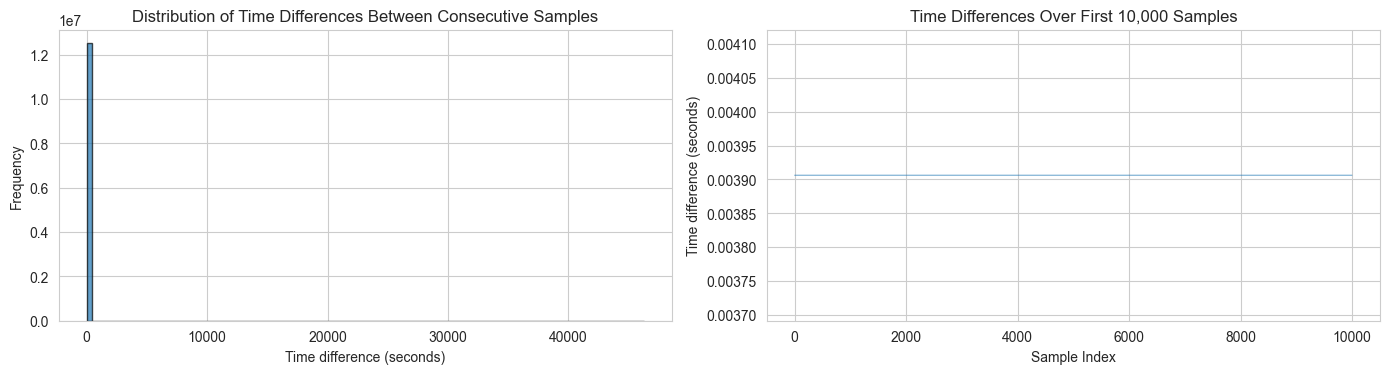

In [18]:
# ==============================
# 2. Determine sampling rate
# ==============================

# Calculate time differences
time_diffs = df_combined['Time'].diff().dropna()
mean_diff = time_diffs.mean()
std_diff = time_diffs.std()

print(f"Time difference statistics:")
print(f"  Mean: {mean_diff:.6f} seconds")
print(f"  Std: {std_diff:.6f} seconds")
print(f"  Min: {time_diffs.min():.6f} seconds")
print(f"  Max: {time_diffs.max():.6f} seconds")

# Calculate sampling rate
fs = 1 / mean_diff if mean_diff > 0 else 250
print(f"\n✓ Sampling rate: {fs:.1f} Hz (expected 250 Hz)")

# Calculate total duration
total_time = df_combined['Time'].max() - df_combined['Time'].min()
total_hours = total_time / 3600
print(f"✓ Total duration: {total_time:,.0f} seconds = {total_hours:.1f} hours")

# Plot time differences to check for anomalies
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.hist(time_diffs, bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('Time difference (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Time Differences Between Consecutive Samples')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(time_diffs.values[:10000], linewidth=0.5)
plt.xlabel('Sample Index')
plt.ylabel('Time difference (seconds)')
plt.title('Time Differences Over First 10,000 Samples')
plt.grid(True)
plt.tight_layout()
plt.show()

## Bước 3: Chuẩn Hóa Giá Trị Voltage (Min-Max Normalization)

In [ ]:
# ==============================
# 3. Normalize Voltage (Min-Max)
# ==============================

print("=" * 70)
print("VOLTAGE NORMALIZATION (MIN-MAX)")
print("=" * 70)

# Get original min/max
min_voltage = df_combined['Voltage'].min()
max_voltage = df_combined['Voltage'].max()

print(f"\nOriginal Voltage:")
print(f"  Min: {min_voltage:.6f}")
print(f"  Max: {max_voltage:.6f}")
print(f"  Range: {max_voltage - min_voltage:.6f}")

# Apply min-max normalization
voltage_normalized = (df_combined['Voltage'] - min_voltage) / (max_voltage - min_voltage)

print(f"\nAfter Min-Max Normalization:")
print(f"  Min: {voltage_normalized.min():.6f}")
print(f"  Max: {voltage_normalized.max():.6f}")

# Update dataframe
df_combined['Voltage'] = voltage_normalized

# Plot before/after
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
all_data_voltage = [df['Voltage'].values for df in all_data[:5]]
for i, vol in enumerate(all_data_voltage):
    plt.plot(vol[:5000], alpha=0.6, label=f'File {i}')
plt.xlabel('Sample Index')
plt.ylabel('Original Voltage')
plt.title('Original Voltage (First 5 Files, 5000 samples)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
normalized_voltage = df_combined['Voltage'].values[:25000]
plt.plot(normalized_voltage, alpha=0.6)
plt.xlabel('Sample Index')
plt.ylabel('Normalized Voltage')
plt.title('Normalized Voltage (First 25000 samples)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Save normalization parameters for later use
norm_params = {
    'min_voltage': float(min_voltage),
    'max_voltage': float(max_voltage)
}
print(f"\n✓ Normalization parameters saved")

## Bước 4: Xử Lý Outliers (IQR Method)

In [ ]:
# ==============================
# 5. Create sliding windows
# ==============================

print("=" * 70)
print("CREATING SLIDING WINDOWS")
print("=" * 70)

window_size = 512
stride = 256  # 50% overlap
fs = 250.0

print(f"\nWindow parameters:")
print(f"  Window size: {window_size} samples")
print(f"  Stride: {stride} samples (50% overlap)")
print(f"  Window duration: {window_size / fs:.3f} seconds")
print(f"  Sampling rate: {fs:.0f} Hz")
print(f"  Using Label source: Label_from_folder (from directory name)")

# Create windows
X = []
y = []
indices = []

# Use numpy arrays for faster processing
voltage_array = df_combined['Voltage'].values
label_array = df_combined['Label_from_folder'].values  # Use label from folder name!

n_windows = 0

# Create windows from all data
start_idx = 0
while start_idx + window_size <= len(voltage_array):
    # Extract window
    window_voltage = voltage_array[start_idx:start_idx + window_size]
    window_labels = label_array[start_idx:start_idx + window_size]
    
    # Get majority label for this window
    label_counts = Counter(window_labels)
    most_common_labels = label_counts.most_common()
    
    if len(most_common_labels) > 1:
        # If there's a tie, use the smallest label
        max_count = most_common_labels[0][1]
        tied_labels = [label for label, count in most_common_labels if count == max_count]
        window_label = min(tied_labels)
    else:
        window_label = most_common_labels[0][0]
    
    # Add to arrays
    X.append(window_voltage)
    y.append(window_label)
    indices.append(start_idx)
    n_windows += 1
    
    if n_windows % 50000 == 0:
        print(f"Created {n_windows} windows...")
    
    start_idx += stride

# Convert to numpy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int8)
indices = np.array(indices)

print(f"\n✓ Windows created:")
print(f"  Total windows: {len(X):,}")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")

# Visualize windows statistics
print(f"\nWindows per label (using Label_from_folder):")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    pct = 100 * count / len(y)
    print(f"  Label {label}: {count:,} ({pct:.1f}%)")

## Bước 5: Tạo Sliding Windows (512 mẫu, stride 256)

In [ ]:
# ==============================
# 5. Create sliding windows
# ==============================

print("=" * 70)
print("CREATING SLIDING WINDOWS")
print("=" * 70)

window_size = 512
stride = 256  # 50% overlap
fs = 250.0

print(f"\nWindow parameters:")
print(f"  Window size: {window_size} samples")
print(f"  Stride: {stride} samples (50% overlap)")
print(f"  Window duration: {window_size / fs:.3f} seconds")
print(f"  Sampling rate: {fs:.0f} Hz")

# Create windows
X = []
y = []
indices = []

# Use numpy arrays for faster processing
voltage_array = df_combined['Voltage'].values
label_array = df_combined['Label'].values

n_windows = 0

# Create windows from all data
start_idx = 0
while start_idx + window_size <= len(voltage_array):
    # Extract window
    window_voltage = voltage_array[start_idx:start_idx + window_size]
    window_labels = label_array[start_idx:start_idx + window_size]
    
    # Get majority label for this window
    label_counts = Counter(window_labels)
    most_common_labels = label_counts.most_common()
    
    if len(most_common_labels) > 1:
        # If there's a tie, use the smallest label
        max_count = most_common_labels[0][1]
        tied_labels = [label for label, count in most_common_labels if count == max_count]
        window_label = min(tied_labels)
    else:
        window_label = most_common_labels[0][0]
    
    # Add to arrays
    X.append(window_voltage)
    y.append(window_label)
    indices.append(start_idx)
    n_windows += 1
    
    if n_windows % 50000 == 0:
        print(f"Created {n_windows} windows...")
    
    start_idx += stride

# Convert to numpy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int8)
indices = np.array(indices)

print(f"\n✓ Windows created:")
print(f"  Total windows: {len(X):,}")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")

# Visualize windows statistics
print(f"\nWindows per label:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    pct = 100 * count / len(y)
    print(f"  Label {label}: {count:,} ({pct:.1f}%)")

## Bước 6: Kiểm Tra Cân Bằng Nhãn (Class Balance)

In [ ]:
# ==============================
# 6. Check class balance
# ==============================

print("=" * 70)
print("CLASS BALANCE ANALYSIS")
print("=" * 70)

# Count samples per class
unique_labels, label_counts = np.unique(y, return_counts=True)
class_distribution = dict(zip(unique_labels, label_counts))

print(f"\nLabel distribution:")
for label in sorted(class_distribution.keys()):
    count = class_distribution[label]
    pct = 100 * count / len(y)
    print(f"  Label {label}: {count:,} ({pct:.1f}%)")

# Calculate imbalance ratio
max_count = max(label_counts)
min_count = min(label_counts)
imbalance_ratio = max_count / min_count

print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio < 3:
    print("✓ Relatively balanced (ratio < 3:1) - No need for resampling")
    use_class_weights = True
else:
    print("⚠ Imbalanced (ratio >= 3:1) - Consider using class weights or SMOTE")
    use_class_weights = True

# Calculate class weights
n_classes = len(np.unique(y))
class_weights = {}
total_samples = len(y)

for label in unique_labels:
    weight = total_samples / (n_classes * class_distribution[label])
    class_weights[label] = weight

print(f"\nClass weights (for training):")
for label in sorted(class_weights.keys()):
    print(f"  Label {label}: {class_weights[label]:.4f}")

# Visualize class distribution
plt.figure(figsize=(10, 5))
plt.bar(unique_labels, label_counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.xlabel('Label')
plt.ylabel('Number of Windows')
plt.title('Class Distribution (Before Train/Val/Test Split)')
plt.grid(axis='y', alpha=0.3)
for i, (label, count) in enumerate(zip(unique_labels, label_counts)):
    plt.text(label, count, f'{count:,}\n({100*count/total_samples:.1f}%)', 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Bước 7: Train/Val/Test Split (Stratified - 60/20/20)

In [ ]:
# ==============================
# 7. Stratified train/val/test split
# ==============================

print("=" * 70)
print("STRATIFIED TRAIN/VAL/TEST SPLIT (60/20/20)")
print("=" * 70)

# Split 1: Train vs. (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.4,  # 40% for val + test
    stratify=y, 
    random_state=42
)

# Split 2: Val vs. Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,  # 50% of temp = 20% of total
    stratify=y_temp,
    random_state=42
)

print(f"\nData split sizes:")
print(f"  Train: {len(X_train):,} windows ({100*len(X_train)/len(X):.1f}%)")
print(f"  Val:   {len(X_val):,} windows ({100*len(X_val)/len(X):.1f}%)")
print(f"  Test:  {len(X_test):,} windows ({100*len(X_test)/len(X):.1f}%)")

# Check label distribution in each split
print(f"\nLabel distribution in each split:")
print(f"\n{'Label':<8} {'Train':<12} {'Val':<12} {'Test':<12}")
print("-" * 44)

for label in sorted(np.unique(y)):
    train_count = np.sum(y_train == label)
    val_count = np.sum(y_val == label)
    test_count = np.sum(y_test == label)
    
    train_pct = 100 * train_count / len(y_train)
    val_pct = 100 * val_count / len(y_val)
    test_pct = 100 * test_count / len(y_test)
    
    print(f"{label:<8} {train_count:,} ({train_pct:>5.1f}%)   {val_count:,} ({val_pct:>5.1f}%)   {test_count:,} ({test_pct:>5.1f}%)")

# Visualize splits
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

splits = [
    ('Train', y_train),
    ('Validation', y_val),
    ('Test', y_test)
]

for ax, (split_name, split_labels) in zip(axes, splits):
    unique, counts = np.unique(split_labels, return_counts=True)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    ax.bar(unique, counts, color=colors)
    ax.set_xlabel('Label')
    ax.set_ylabel('Number of Windows')
    ax.set_title(f'{split_name} Set Distribution\n(Total: {len(split_labels):,})')
    ax.grid(axis='y', alpha=0.3)
    
    # Add labels on bars
    for i, (label, count) in enumerate(zip(unique, counts)):
        pct = 100 * count / len(split_labels)
        ax.text(label, count, f'{count:,}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n✓ Train/Val/Test split completed successfully")

## Bước 8: Lưu Dữ Liệu Đã Xử Lý

In [ ]:
# ==============================
# 8. Save preprocessed data
# ==============================

print("=" * 70)
print("SAVING PREPROCESSED DATA")
print("=" * 70)

# Create output directory
output_dir = "data/preprocessed"
os.makedirs(output_dir, exist_ok=True)

# Save numpy arrays
np.save(f"{output_dir}/X_train.npy", X_train)
np.save(f"{output_dir}/y_train.npy", y_train)
np.save(f"{output_dir}/X_val.npy", X_val)
np.save(f"{output_dir}/y_val.npy", y_val)
np.save(f"{output_dir}/X_test.npy", X_test)
np.save(f"{output_dir}/y_test.npy", y_test)

print(f"\n✓ Saved numpy arrays:")
print(f"  X_train.npy: {X_train.nbytes / 1e6:.1f} MB")
print(f"  y_train.npy: {y_train.nbytes / 1e6:.3f} MB")
print(f"  X_val.npy:   {X_val.nbytes / 1e6:.1f} MB")
print(f"  y_val.npy:   {y_val.nbytes / 1e6:.3f} MB")
print(f"  X_test.npy:  {X_test.nbytes / 1e6:.1f} MB")
print(f"  y_test.npy:  {y_test.nbytes / 1e6:.3f} MB")

# Create metadata
metadata = {
    "label_source": "Label_from_folder (derived from directory name: pure_0, pure_1, mixed_0, etc.)",
    "normalization": {
        "method": "minmax",
        "min_voltage": float(min_voltage),
        "max_voltage": float(max_voltage)
    },
    "class_weights": {str(int(k)): float(v) for k, v in class_weights.items()},
    "shapes": {
        "X_train": list(X_train.shape),
        "y_train": list(y_train.shape),
        "X_val": list(X_val.shape),
        "y_val": list(y_val.shape),
        "X_test": list(X_test.shape),
        "y_test": list(y_test.shape)
    },
    "window_config": {
        "window_size": int(window_size),
        "stride": int(stride),
        "sampling_rate_hz": int(fs)
    },
    "label_distribution": {
        "train": {str(int(k)): int(v) for k, v in dict(zip(*np.unique(y_train, return_counts=True))).items()},
        "val": {str(int(k)): int(v) for k, v in dict(zip(*np.unique(y_val, return_counts=True))).items()},
        "test": {str(int(k)): int(v) for k, v in dict(zip(*np.unique(y_test, return_counts=True))).items()}
    },
    "outliers_removed": int(n_outliers),
    "outliers_pct": float(pct_outliers),
    "imbalance_ratio": float(imbalance_ratio)
}

# Save metadata
with open(f"{output_dir}/preprocessing_stats.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n✓ Saved preprocessing_stats.json")

# Print summary
print(f"\n" + "=" * 70)
print("PREPROCESSING SUMMARY")
print("=" * 70)
print(json.dumps(metadata, indent=2))

print(f"\n{'='*70}")
print("✅ PREPROCESSING COMPLETED SUCCESSFULLY!")
print(f"{'='*70}")
print(f"Output directory: {os.path.abspath(output_dir)}")
print(f"\nLabel Source: Label_from_folder (derived from folder name)")
print(f"Files saved:")
print(f"  - X_train.npy, y_train.npy")
print(f"  - X_val.npy, y_val.npy")
print(f"  - X_test.npy, y_test.npy")
print(f"  - preprocessing_stats.json")

## Summary & Next Steps

### Đã Hoàn Thành:
✅ Load concatenated ECG data từ `data/concatenated/`
✅ Kiểm tra chất lượng dữ liệu (missing values, duplicates, ranges)
✅ Xác định sampling rate (250 Hz)
✅ Chuẩn hóa Voltage sử dụng Min-Max normalization
✅ Loại bỏ outliers sử dụng IQR method
✅ Tạo sliding windows (512 mẫu, stride 256)
✅ Kiểm tra class balance
✅ Chia train/val/test set theo tỷ lệ 60/20/20 (stratified)
✅ Lưu dữ liệu preprocessed thành `.npy` files + metadata JSON

### Output Files:
```
data/preprocessed/
├── X_train.npy          # Shape: (N_train, 512)
├── y_train.npy          # Shape: (N_train,)
├── X_val.npy            # Shape: (N_val, 512)
├── y_val.npy            # Shape: (N_val,)
├── X_test.npy           # Shape: (N_test, 512)
├── y_test.npy           # Shape: (N_test,)
└── preprocessing_stats.json
```

### Bước Tiếp Theo:
👉 Sử dụng `X_train`, `y_train` (không phải `X_val`, `y_val`, `X_test` - để tránh data leakage)
👉 Xây dựng và huấn luyện mô hình (CNN, LSTM, hoặc hybrid model)
👉 Sử dụng `class_weights` từ `preprocessing_stats.json` trong loss function
👉 Đánh giá trên `X_val` và `X_test`

### Important Notes:
⚠️ **Data Leakage Prevention:**
- Normalization parameters (min/max) được tính CHỈ từ data gốc trước khi split
- Áp dụng CHUNG cho train/val/test
- KHÔNG tính lại normalization từ val/test

⚠️ **Class Imbalance:**
- Các class weights đã được tính sẵn trong `preprocessing_stats.json`
- Sử dụng trong training: `model.fit(..., class_weight=class_weights)`

⚠️ **Sliding Window Overlap:**
- Windows có 50% overlap (stride = 256 / window_size = 512)
- Tăng số lượng training samples
- Kéo dài training time nhưng cải thiện model generalization